# S14: Properties of the integral. Functions defined as integrals.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

import sympy as sy
from sympy import Function, diff, Piecewise, integrate, Symbol, latex
from sympy.plotting import plot

from IPython.display import Math, display

import ipywidgets as widgets
from ipywidgets import interact


## Functions defined as integrals

Let us define the following piecewise function:
$$
f(x) = \begin{cases}x & \text{ si }0 \leq x \leq 1\\0 & \text{en otro caso}\end{cases}
$$  


In [13]:
x = Symbol('x')

f = Piecewise((x, (x >= 0) & (x <= 1)), (0, True))

display(Math(f"f(x) = {latex(f)}"))

<IPython.core.display.Math object>

Let us plot the piecewise function:

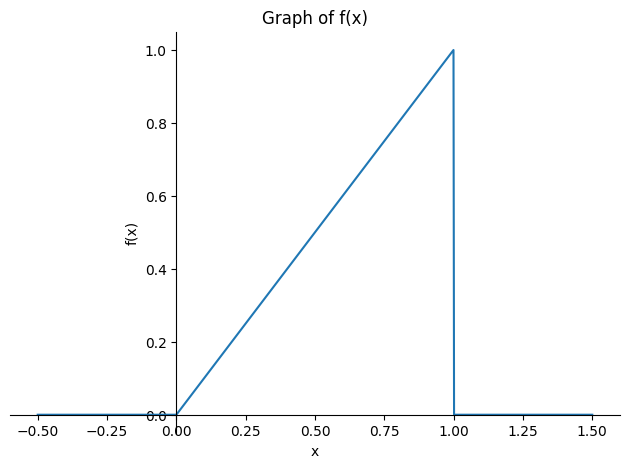

In [16]:
p = plot(f, (x, -0.5, 1.5), title="Graph of f(x)", xlabel="x", ylabel="f(x)", show=True)

Now let us define $F(x)= \displaystyle\int_0^x f(t)\, dt$

In [17]:
t = Symbol('t')

f_t = f.subs(x, t)
F = integrate(f_t, (t, 0, x))

display(Math(f"F(x) = {latex(F)}"))

<IPython.core.display.Math object>

The plot of this function is as follows:

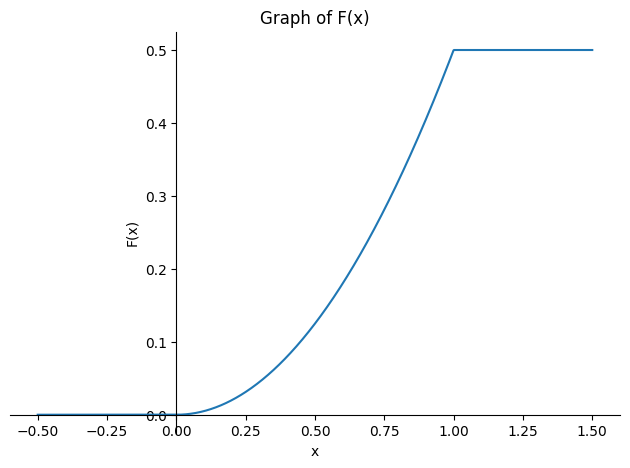

In [18]:
p_F = plot(F, (x, -0.5, 1.5), title="Graph of F(x)", xlabel="x", ylabel="F(x)", show=True)

Notice how $f(x)$ was discontinuous at $x = 1$, but $F(x)$ is continuous. What happens if we ask sympy to find the derivative of $f(x)$

In [19]:
df = diff(f, x)
display(Math(f"f'(x) = {latex(df)}"))

<IPython.core.display.Math object>

As you can see, this equals $f(x)$.

### A second example

Let us now consider
$$
g(x) = \begin{cases}
    0   & \text{ si }x < 0\\
2 - 2 x &\text{ si }0 \leq x \leq 2\\
2 x - 6 &\text{ si }0 \leq x \leq 2\\
    0   &\text{ si }x > 3\end{cases}
$$  

In [25]:
g = Piecewise(
    (0, x < 0),
    (2 - 2*x, (x >= 0) & (x <= 2)),
    (2*x - 6, (x > 2) & (x <= 3)),
    (0, x > 3)
)

display(Math(f"g(x) = {latex(g)}"))

<IPython.core.display.Math object>

Let us plot the piecewise function $g(x)$:

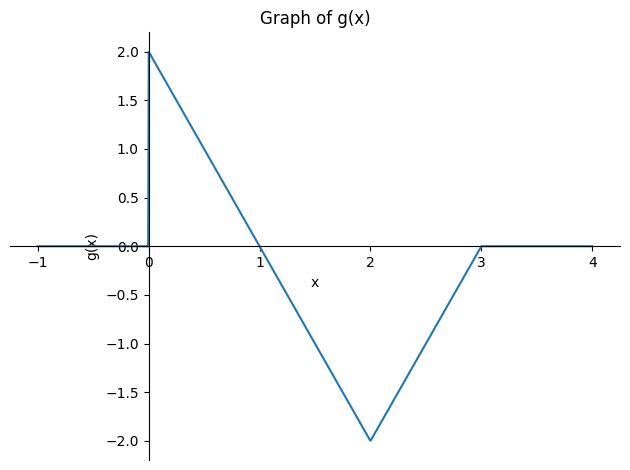

In [26]:
p_g = plot(g, (x, -1, 4), title="Graph of g(x)", xlabel="x", ylabel="g(x)", show=True)

Now let us define the integral function $G(x) = \int_0^x g(t)\, dt$:

In [27]:
g_t = g.subs(x, t)
G = integrate(g_t, (t, 0, x))

display(Math(f"G(x) = {latex(G)}"))

<IPython.core.display.Math object>

The plot of $G(x)$ is as follows:

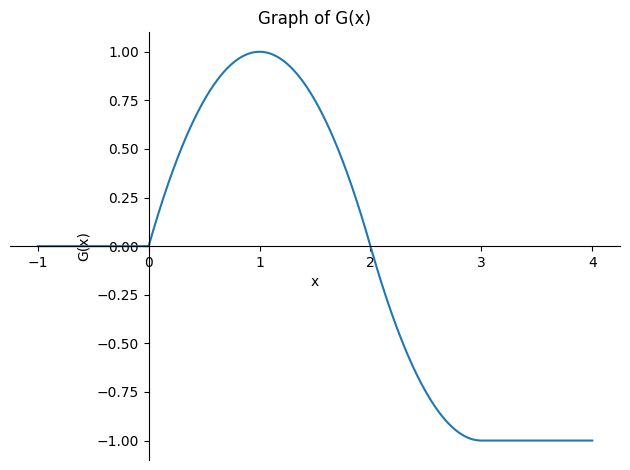

In [28]:
p_G = plot(G, (x, -1, 4), title="Graph of G(x)", xlabel="x", ylabel="G(x)", show=True)

Note that $g$ was discontinuous at 0, but $G$ is continuous there. Besides, $g$ had no derivative at 2, but $G$ is derivableat that point. These results show what we discuss in this lecture: integrating a function makes it *more regular*.


What happens if we ask sympy to find the derivative of $G(x)$? Let's verify:

In [44]:
dG = diff(G, x)
display(Math(f"G'(x) = {latex(dG)}"))

<IPython.core.display.Math object>

where
$$
\theta(x) = \begin{cases} 0 & \text{for } x < 0 \\ 1 & \text{for } x \ge 0 \end{cases}
$$
is the **Heaviside step function** (often called $u(x)$ in Signal Processing). This function is often used to obtain simple analytical expressions of piecewise defined functions (instead of using braces). For example if you want a function that equals $sin(x)$ between $\pi$ and $13\frac{\pi}{2}$ and equals 0 elsewhere you can do:

In [45]:
from sympy import Heaviside
theta = Heaviside

h = sy.sin(x) * (theta(x - sy.pi) - theta(x - 13 * sy.pi / 2))
display(Math(f"h(x) = {latex(h)}"))

<IPython.core.display.Math object>

Let us plot it to see that it matches our desired function:

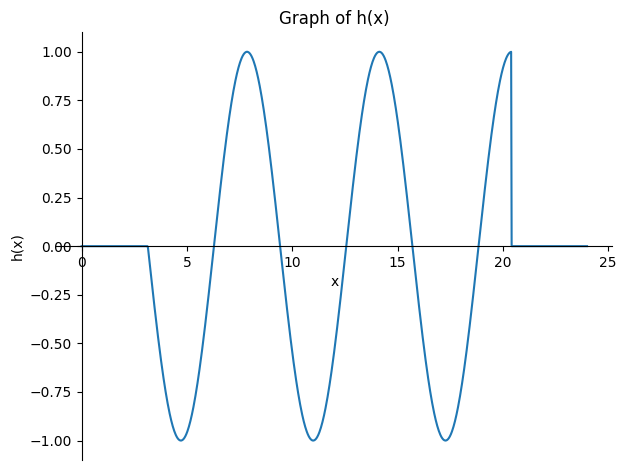

In [46]:
plot(h, (x, 0, 24), title="Graph of h(x)", xlabel="x", ylabel="h(x)", show=True)